In [52]:
from sklearn.datasets import fetch_california_housing

In [53]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [54]:
# Select feature (MedInc) and target (MedHouseVal)
X = df[["MedInc"]]
y = df[["MedHouseVal"]]

In [55]:
from sklearn.preprocessing import PolynomialFeatures

In [56]:
# Transform featurs to polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
print(X_poly)

[[ 8.3252     69.30895504]
 [ 8.3014     68.91324196]
 [ 7.2574     52.66985476]
 ...
 [ 1.7         2.89      ]
 [ 1.8672      3.48643584]
 [ 2.3886      5.70540996]]


In [57]:
from sklearn.linear_model import LinearRegression

In [58]:
# Fit polynomial regression model
model = LinearRegression()
model.fit(X_poly, y)

# Make predictions
y_pred = model.predict(X_poly)

In [59]:
import matplotlib.pyplot as plt

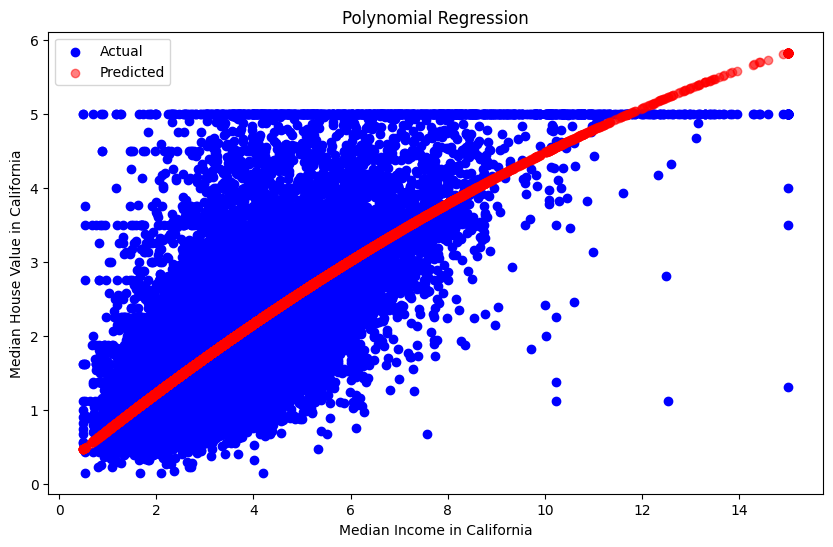

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="Actual")
plt.scatter(X, y_pred, color="red", label="Predicted", alpha=0.5)
plt.title("Polynomial Regression")
plt.xlabel("Median Income in California")
plt.ylabel("Median House Value in California")
plt.legend()
plt.show()

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

In [62]:
# Evaluate model
print(f"MSE: {mean_squared_error(y, y_pred)}")
print(f"R2: {r2_score(y, y_pred)}")

MSE: 0.695037253723973
R2: 0.47802403432955454


In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.linear_model import Ridge, Lasso

In [66]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

In [67]:
# Evaluate Ridge model
print(f"Ridge MSE: {mean_squared_error(y_test, ridge_pred)}")
print(f"Ridge R2 Score: {r2_score(y_test, ridge_pred)}")

Ridge MSE: 0.703272792117919
Ridge R2 Score: 0.4633180909199841


In [68]:
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

In [69]:
# Evaluate Lasso model
print(f"Lasso MSE: {mean_squared_error(y_test, lasso_pred)}")
print(f"Lasso R2 Score: {r2_score(y_test, lasso_pred)}")

Lasso MSE: 0.8150896447059206
Lasso R2 Score: 0.3779883545974315


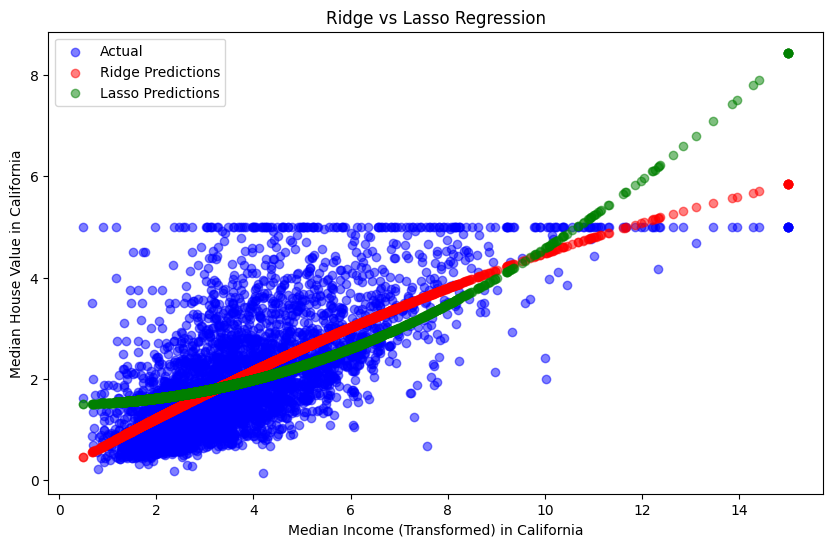

In [70]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color="blue", label="Actual", alpha=0.5)
plt.scatter(X_test[:, 0], ridge_pred, color="red", label="Ridge Predictions", alpha=0.5)
plt.scatter(
    X_test[:, 0], lasso_pred, color="green", label="Lasso Predictions", alpha=0.5
)
plt.title("Ridge vs Lasso Regression")
plt.xlabel("Median Income (Transformed) in California")
plt.ylabel("Median House Value in California")
plt.legend()
plt.show()